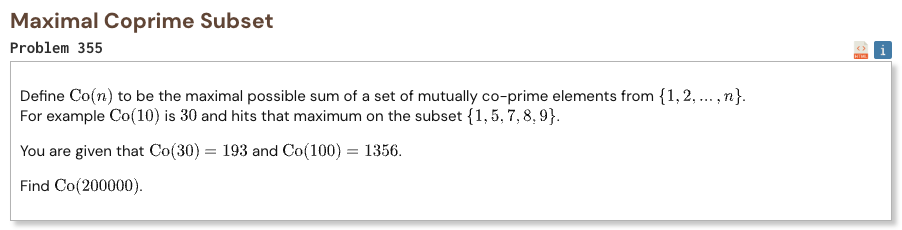

## Initial approach

* start with one prime-power choice for every prime
* this gives a valid coprime baseline set
* sometimes combining one small prime with one larger prime gives a better number
* the improvement is the combined number minus the two separate baseline numbers
* each prime can be used only once, so these improvements form a matching problem
* use min-cost flow to choose the best non-conflicting improvements
* use collections deque for shortest path search in the flow graph

In [1]:
import math
from collections import deque

def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            start = p * p
            is_prime[start:limit + 1:p] = b"\x00" * (((limit - start) // p) + 1)

    return [i for i in range(limit + 1) if is_prime[i]]

def max_prime_power(p, limit):
    value = p

    while value * p <= limit:
        value *= p

    return value

class MinCostFlow:
    def __init__(self, size):
        self.size = size
        self.graph = [[] for _ in range(size)]

    def add_edge(self, u, v, capacity, cost):
        self.graph[u].append([v, capacity, cost, len(self.graph[v])])
        self.graph[v].append([u, 0, -cost, len(self.graph[u]) - 1])

    def min_cost_flow(self, source, sink, flow):
        total_cost = 0

        for _ in range(flow):
            distance = [10 ** 30] * self.size
            in_queue = [False] * self.size
            previous_node = [-1] * self.size
            previous_edge = [-1] * self.size

            distance[source] = 0
            queue = deque([source])
            in_queue[source] = True

            while queue:
                u = queue.popleft()
                in_queue[u] = False

                for edge_index, edge in enumerate(self.graph[u]):
                    v, capacity, cost, reverse_index = edge

                    if capacity > 0 and distance[u] + cost < distance[v]:
                        distance[v] = distance[u] + cost
                        previous_node[v] = u
                        previous_edge[v] = edge_index

                        if not in_queue[v]:
                            queue.append(v)
                            in_queue[v] = True

            if distance[sink] >= 0:
                break

            total_cost += distance[sink]
            v = sink

            while v != source:
                u = previous_node[v]
                edge_index = previous_edge[v]
                edge = self.graph[u][edge_index]

                edge[1] -= 1
                self.graph[v][edge[3]][1] += 1
                v = u

        return total_cost

def Co(limit):
    primes = prime_sieve(limit)
    root = math.isqrt(limit)

    prime_power = {p: max_prime_power(p, limit) for p in primes}
    baseline = 1 + sum(prime_power.values())

    small_primes = [p for p in primes if p <= root]
    large_primes = [p for p in primes if root < p <= limit // 2]

    source = 0
    small_start = 1
    large_start = small_start + len(small_primes)
    sink = large_start + len(large_primes)

    flow = MinCostFlow(sink + 1)

    for i, p in enumerate(small_primes):
        flow.add_edge(source, small_start + i, 1, 0)
        flow.add_edge(small_start + i, sink, 1, 0)

    for j, q in enumerate(large_primes):
        flow.add_edge(large_start + j, sink, 1, 0)

    for i, p in enumerate(small_primes):
        separate = prime_power[p]

        for j, q in enumerate(large_primes):
            if p * q > limit:
                break

            power = 1

            while power * p * q <= limit:
                power *= p

            combined = power * q
            gain = combined - separate - q

            if gain > 0:
                flow.add_edge(small_start + i, large_start + j, 1, -gain)

    best_gain = -flow.min_cost_flow(source, sink, len(small_primes))
    return baseline + best_gain

In [2]:
%%time
result = Co(200000)
print("Result:", result)

Result: 1726545007
CPU times: user 521 ms, sys: 17 ms, total: 538 ms
Wall time: 593 ms
